# 4. Feature clustering, ablation and explainability

Everything here is a post-development analysis of a model that was frozen in
notebook 3. Nothing is refitted, no threshold moves and no configuration is
selected, so none of it can feed back into model selection.

Ablation and importance describe how the frozen model uses its inputs. They are
not tests of incremental predictive value: that question is answered by the
paired comparisons in notebook 3.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform
from sklearn.metrics import f1_score

import config
import ensemble as ens
import train
import utils

utils.ensure_dirs()
utils.set_seed()

HORIZON = config.HORIZONS[0]
ARM = f"h{HORIZON}_{config.PRIMARY_THYROID}_paper"
print("explaining frozen arm:", ARM)

explaining frozen arm: h7_CV17_THY_CONT_paper


In [2]:
bundle = train.load_model(f"final_{ARM}")
predictions = train.load_test_predictions(ARM)
threshold = bundle["threshold"]
feature_set = bundle["feature_set"]

strict = utils.read_frame(str(config.COHORT_STRICT).format(horizon=HORIZON))
splits = utils.load_splits(HORIZON)
X, y, ids = utils.extract_xy(strict, feature_set)
masks = utils.split_masks(ids, splits)

X_train, y_train = X[masks["train"]], y[masks["train"]]
X_test, y_test = X[masks["test"]], y[masks["test"]]
utils.assert_same_patients(ids[masks["test"]],
                           predictions[config.ID_COL].to_numpy())
print(f"features: {X.shape[1]} | train {len(X_train)} | test {len(X_test)}")

features: 20 | train 2634 | test 878


In [3]:
def frozen_proba(frame):
    """Frozen ensemble probability for an arbitrary feature matrix."""
    parts = [pipe.predict_proba(frame)[:, 1]
             for pipe in bundle["members"].values()]
    return train.apply_calibrator(bundle["calibrator"], ens.mean_proba(parts))


baseline_proba = frozen_proba(X_test)
stored = predictions["proba_calibrated"].to_numpy()
assert np.allclose(baseline_proba, stored, atol=1e-9)
baseline_f1 = f1_score(y_test, (baseline_proba >= threshold).astype(int),
                       average="macro")
print(f"frozen test macro-F1 reproduced from the stored model: {baseline_f1:.4f}")

frozen test macro-F1 reproduced from the stored model: 0.7597


## 4.1 Hierarchical feature clustering

Distance is `1 - abs(Spearman)`, as in the paper, with seven clusters. The
structure is estimated on the training partition only, because it is then used
to define cluster ablations evaluated on test. Clustering is descriptive: a
tight cluster is not evidence of predictive importance.

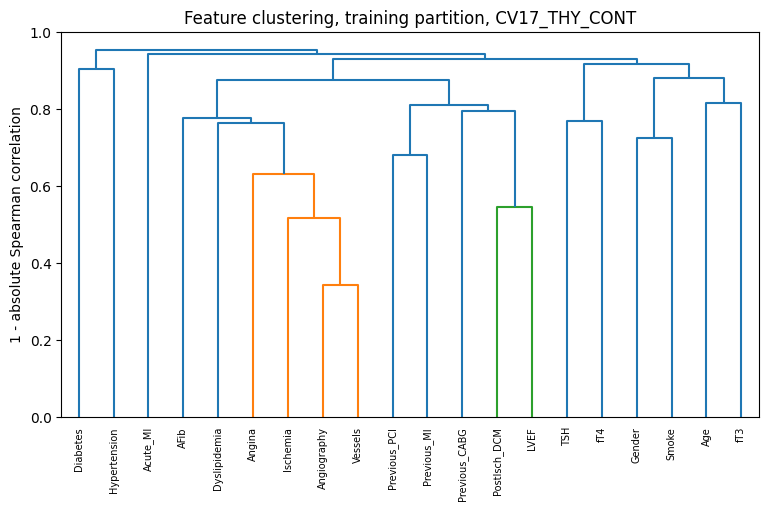

,feature,cluster,block
12,Diabetes,1,cardiovascular
13,Hypertension,2,cardiovascular
15,AFib,3,cardiovascular
2,Angina,3,cardiovascular
7,Angiography,3,cardiovascular
14,Dyslipidemia,3,cardiovascular
9,Ischemia,3,cardiovascular
16,LVEF,3,cardiovascular
10,PostIsch_DCM,3,cardiovascular
3,Previous_CABG,3,cardiovascular


In [4]:
correlation = X_train.corr(method="spearman").fillna(0.0)
distance = 1.0 - correlation.abs()
np.fill_diagonal(distance.values, 0.0)
linkage_matrix = linkage(squareform(distance.values, checks=False), method="average")
labels = fcluster(linkage_matrix, t=config.N_FEATURE_CLUSTERS, criterion="maxclust")

clusters = pd.DataFrame({"feature": X_train.columns, "cluster": labels})
clusters["block"] = np.where(clusters["feature"].isin(config.CARDIO),
                             "cardiovascular", "thyroid")
utils.save_result(clusters, f"feature_clusters_{ARM}")

fig, ax = plt.subplots(figsize=(9, 5))
dendrogram(linkage_matrix, labels=list(X_train.columns), ax=ax,
           leaf_font_size=7, color_threshold=None)
ax.set_ylabel("1 - absolute Spearman correlation")
ax.set_title(f"Feature clustering, training partition, {feature_set}")
plt.xticks(rotation=90)
utils.save_fig(fig, f"feature_clusters_{ARM}")
plt.show()
clusters.sort_values(["cluster", "feature"])

## 4.2 Ablation on the frozen test partition

A variable is knocked out by replacing it with a training-derived reference
value and re-predicting with the frozen model. The importance ratio follows the
paper, `baseline macro-F1 / ablated macro-F1`, computed without rounding, and is
reported next to the absolute difference. Uncertainty comes from a paired
bootstrap over the test patients, so the frozen test set is never re-split.

For a binary dummy the training mean is a prevalence, not a physiological
value, so those knock-outs answer "what if this indicator carried no patient
specific information" rather than describing a real clinical state.

In [5]:
reference_values = X_train.mean(numeric_only=True)


def ablate(columns):
    modified = X_test.copy()
    for column in columns:
        modified[column] = reference_values[column]
    return frozen_proba(modified)


def ablation_row(name, columns, kind):
    proba = ablate(columns)
    pred_base = (baseline_proba >= threshold).astype(int)
    pred_ablated = (proba >= threshold).astype(int)
    ablated_f1 = f1_score(y_test, pred_ablated, average="macro")

    draws = utils.bootstrap_indices(len(y_test), config.BOOTSTRAP, config.SEED)
    ratios, diffs = [], []
    for idx in draws:
        if y_test[idx].min() == y_test[idx].max():
            continue
        base = f1_score(y_test[idx], pred_base[idx], average="macro")
        other = f1_score(y_test[idx], pred_ablated[idx], average="macro")
        if other > 0:
            ratios.append(base / other)
        diffs.append(base - other)
    ratio_lo, ratio_hi = utils.bootstrap_ci(ratios)
    diff_lo, diff_hi = utils.bootstrap_ci(diffs)
    return {
        "kind": kind, "name": name, "n_variables": len(columns),
        "block": ("thyroid" if all(c not in config.CARDIO for c in columns)
                  else "cardiovascular" if all(c in config.CARDIO for c in columns)
                  else "mixed"),
        "baseline_f1_macro": baseline_f1,
        "ablated_f1_macro": ablated_f1,
        "importance_ratio": baseline_f1 / ablated_f1 if ablated_f1 > 0 else np.nan,
        "importance_ratio_ci_lo": ratio_lo, "importance_ratio_ci_hi": ratio_hi,
        "absolute_f1_drop": baseline_f1 - ablated_f1,
        "absolute_f1_drop_ci_lo": diff_lo, "absolute_f1_drop_ci_hi": diff_hi,
    }


rows = [ablation_row(column, [column], "single variable") for column in X_test.columns]
for cluster_id in sorted(clusters["cluster"].unique()):
    members = list(clusters.loc[clusters["cluster"] == cluster_id, "feature"])
    rows.append(ablation_row(f"cluster {cluster_id}: " + ", ".join(members),
                             members, "cluster"))
thyroid_block = [c for c in X_test.columns if c not in config.CARDIO]
if thyroid_block:
    rows.append(ablation_row("complete thyroid block", thyroid_block, "block"))

ablation = pd.DataFrame(rows).sort_values(
    ["kind", "importance_ratio"], ascending=[True, False])
utils.save_result(ablation, f"ablation_{ARM}")
ablation[ablation["kind"] == "single variable"][
    ["name", "block", "importance_ratio", "importance_ratio_ci_lo",
     "importance_ratio_ci_hi", "absolute_f1_drop"]].round(4)

,name,block,importance_ratio,importance_ratio_ci_lo,importance_ratio_ci_hi,absolute_f1_drop
1,Age,cardiovascular,1.1337,1.0704,1.2071,0.0896
16,LVEF,cardiovascular,1.0442,1.0008,1.0937,0.0321
14,Dyslipidemia,cardiovascular,1.0404,1.0099,1.0752,0.0295
12,Diabetes,cardiovascular,1.0322,1.0108,1.0570,0.0237
8,Vessels,cardiovascular,1.0264,1.0101,1.0466,0.0196
10,PostIsch_DCM,cardiovascular,1.0248,1.0038,1.0480,0.0184
15,AFib,cardiovascular,1.0247,1.0054,1.0487,0.0183
19,fT4,thyroid,1.0175,0.9947,1.0423,0.0131
6,Acute_MI,cardiovascular,1.0156,1.0000,1.0334,0.0116
9,Ischemia,cardiovascular,1.0140,1.0000,1.0300,0.0105


In [6]:
ablation[ablation["kind"] != "single variable"][
    ["kind", "name", "n_variables", "importance_ratio", "importance_ratio_ci_lo",
     "importance_ratio_ci_hi", "absolute_f1_drop", "absolute_f1_drop_ci_lo",
     "absolute_f1_drop_ci_hi"]].round(4)

,kind,name,n_variables,importance_ratio,importance_ratio_ci_lo,importance_ratio_ci_hi,absolute_f1_drop,absolute_f1_drop_ci_lo,absolute_f1_drop_ci_hi
27,block,complete thyroid block,3,1.0105,0.9886,1.0345,0.0079,-0.0088,0.0253
22,cluster,"cluster 3: Angina, Previous_CABG, Previous_PCI...",11,1.2715,1.1757,1.3739,0.1622,0.1116,0.2107
25,cluster,"cluster 6: Age, fT3",2,1.1164,1.0567,1.1864,0.0792,0.0401,0.1205
20,cluster,cluster 1: Diabetes,1,1.0322,1.0108,1.0570,0.0237,0.0081,0.0412
26,cluster,cluster 7: Acute_MI,1,1.0156,1.0000,1.0334,0.0116,-0.0000,0.0246
23,cluster,"cluster 4: TSH, fT4",2,1.0104,0.9886,1.0359,0.0078,-0.0088,0.0261
21,cluster,cluster 2: Hypertension,1,1.0068,1.0000,1.0176,0.0051,0.0000,0.0131
24,cluster,"cluster 5: Gender, Smoke",2,1.0035,0.9925,1.0152,0.0027,-0.0056,0.0115


In [7]:
# An importance ratio above 1 means the knock-out hurt this particular fit. It
# is a descriptive quantity, not a significance test, which is why the interval
# is shown next to it.
single = ablation[ablation["kind"] == "single variable"].copy()
crosses_one = ((single["importance_ratio_ci_lo"] <= 1)
               & (single["importance_ratio_ci_hi"] >= 1)).sum()
print(f"{crosses_one} of {len(single)} single-variable intervals include 1")

13 of 20 single-variable intervals include 1


## 4.3 Grouped permutation importance

Permutation importance is computed for the frozen ensemble as a whole, so it
describes the deployed model rather than one component. Groups are permuted
jointly, which keeps correlated variables from masking each other.

In [8]:
def permutation_group(name, columns, n_repeats=10):
    rng = np.random.default_rng(config.SEED)
    drops = []
    for _ in range(n_repeats):
        shuffled = X_test.copy()
        order = rng.permutation(len(shuffled))
        for column in columns:
            shuffled[column] = shuffled[column].to_numpy()[order]
        proba = frozen_proba(shuffled)
        drops.append(baseline_f1 - f1_score(
            y_test, (proba >= threshold).astype(int), average="macro"))
    return {"group": name, "n_variables": len(columns),
            "f1_drop_mean": float(np.mean(drops)),
            "f1_drop_std": float(np.std(drops))}


groups = {
    "all thyroid variables": [c for c in X_test.columns if c not in config.CARDIO],
    "continuous thyroid biomarkers": [c for c in config.THYROID_CONT
                                      if c in X_test.columns],
    "thyroid state indicators": [c for c in config.THYROID_STATES
                                 if c in X_test.columns],
    "all cardiovascular variables": [c for c in config.CARDIO if c in X_test.columns],
}
grouped = pd.DataFrame([permutation_group(name, columns)
                        for name, columns in groups.items() if columns])
utils.save_result(grouped, f"grouped_permutation_importance_{ARM}")
grouped.round(4)

,group,n_variables,f1_drop_mean,f1_drop_std
0,all thyroid variables,3,0.0156,0.0063
1,continuous thyroid biomarkers,3,0.0156,0.0063
2,all cardiovascular variables,17,0.2667,0.0170


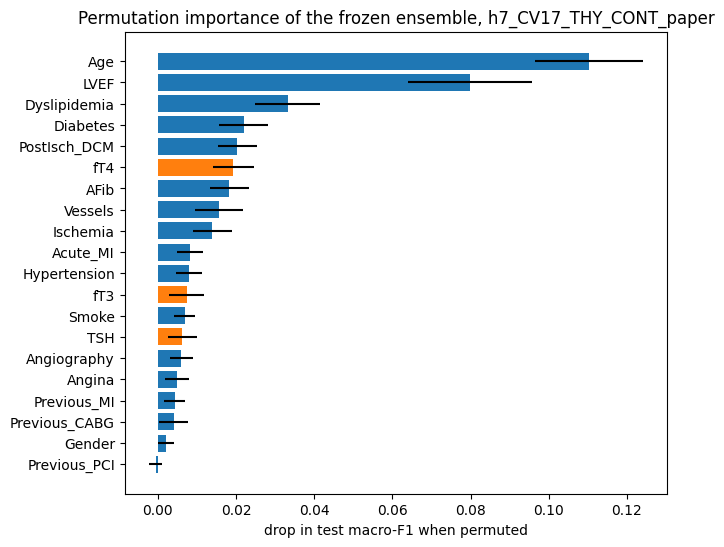

In [9]:
single_perm = pd.DataFrame(
    [permutation_group(column, [column], n_repeats=10) for column in X_test.columns]
).sort_values("f1_drop_mean", ascending=False)
single_perm["block"] = np.where(single_perm["group"].isin(config.CARDIO),
                                "cardiovascular", "thyroid")
utils.save_result(single_perm, f"permutation_importance_{ARM}")

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["tab:blue" if b == "cardiovascular" else "tab:orange"
          for b in single_perm["block"]]
ax.barh(single_perm["group"], single_perm["f1_drop_mean"],
        xerr=single_perm["f1_drop_std"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("drop in test macro-F1 when permuted")
ax.set_title(f"Permutation importance of the frozen ensemble, {ARM}")
utils.save_fig(fig, f"permutation_importance_{ARM}")
plt.show()

## 4.4 SHAP

SHAP is applied to one named tree-based member of the frozen ensemble, not to
the ensemble as a whole. Component-level attributions do not decompose the
averaged ensemble output, so the ensemble-level statement remains the grouped
permutation importance above.

SHAP explains the RandomForest member of the frozen ensemble


C:\Users\ileni\ml4cad\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\ileni\AppData\Local\Temp\ipykernel_19184\2262918012.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values, transformed, show=False, max_display=15)


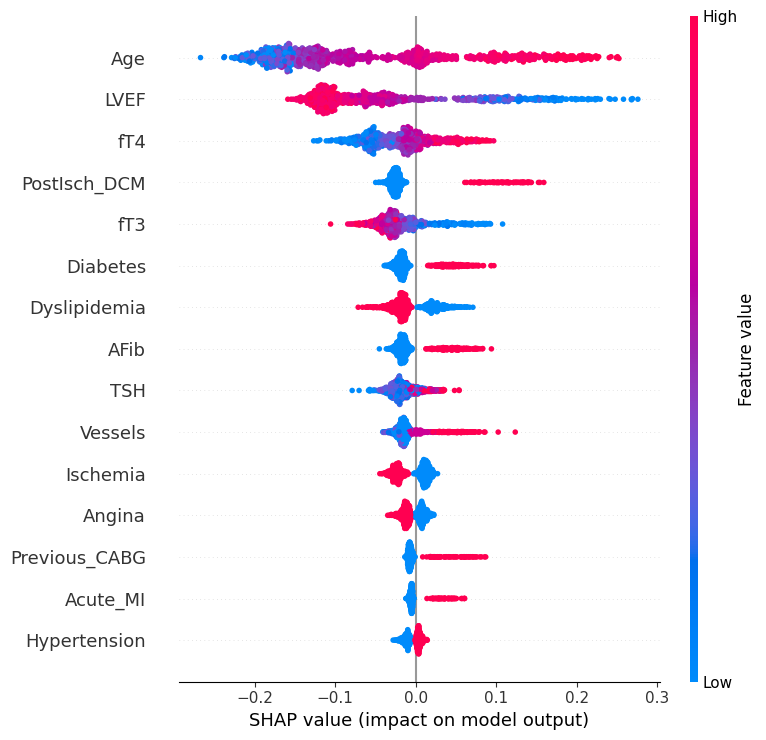

,feature,mean_abs_shap,block,explained_member
1,Age,0.11970,cardiovascular,RandomForest
16,LVEF,0.09404,cardiovascular,RandomForest
19,fT4,0.03636,thyroid,RandomForest
10,PostIsch_DCM,0.03360,cardiovascular,RandomForest
18,fT3,0.03019,thyroid,RandomForest
12,Diabetes,0.02481,cardiovascular,RandomForest
14,Dyslipidemia,0.02238,cardiovascular,RandomForest
15,AFib,0.02230,cardiovascular,RandomForest
17,TSH,0.02001,thyroid,RandomForest
8,Vessels,0.01908,cardiovascular,RandomForest


In [10]:
shap_summary = pd.DataFrame()
if config.RUN_SHAP:
    import shap

    tree_members = [m for m in bundle["members"]
                    if m in ("RandomForest", "GradientBoosting", "XGBoost", "AdaBoost")]
    member_name = tree_members[0]
    pipe = bundle["members"][member_name]
    print(f"SHAP explains the {member_name} member of the frozen ensemble")

    transformed = X_test.copy()
    for step_name, step in pipe.steps[:-1]:
        if hasattr(step, "transform"):
            transformed = pd.DataFrame(step.transform(transformed),
                                       columns=X_test.columns, index=X_test.index)

    explainer = shap.TreeExplainer(pipe.steps[-1][1])
    values = explainer.shap_values(transformed)
    if isinstance(values, list):
        values = values[1]
    if values.ndim == 3:
        values = values[:, :, 1]

    shap_summary = pd.DataFrame({
        "feature": X_test.columns,
        "mean_abs_shap": np.abs(values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)
    shap_summary["block"] = np.where(shap_summary["feature"].isin(config.CARDIO),
                                     "cardiovascular", "thyroid")
    shap_summary["explained_member"] = member_name
    utils.save_result(shap_summary, f"shap_importance_{ARM}")

    fig = plt.figure()
    shap.summary_plot(values, transformed, show=False, max_display=15)
    utils.save_fig(plt.gcf(), f"shap_beeswarm_{ARM}")
    plt.show()
    display(shap_summary.round(5))

In [11]:
if not shap_summary.empty:
    share = (shap_summary.groupby("block")["mean_abs_shap"].sum()
             / shap_summary["mean_abs_shap"].sum() * 100)
    per_feature = (shap_summary.groupby("block")["mean_abs_shap"].mean())
    summary = pd.DataFrame({"share_of_total_percent": share.round(2),
                            "mean_per_feature": per_feature.round(5),
                            "n_features": shap_summary.groupby("block").size()})
    utils.save_result(summary.reset_index(), f"shap_block_summary_{ARM}")
    # The share of total attribution favours whichever block has more columns,
    # so the per-feature mean is reported next to it.
    display(summary)

,share_of_total_percent,mean_per_feature,n_features
block,,,
cardiovascular,82.73,0.02439,17
thyroid,17.27,0.02886,3


<Figure size 640x480 with 0 Axes>

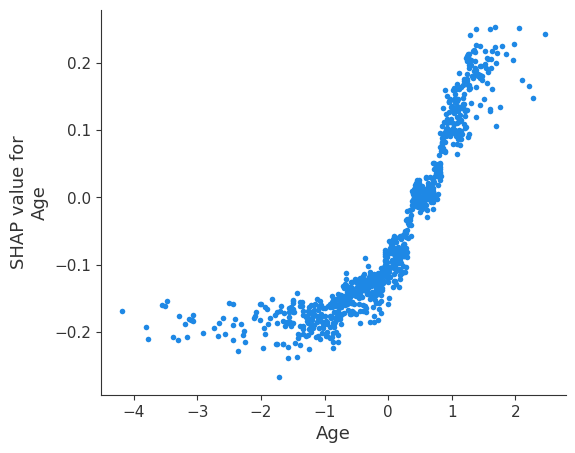

<Figure size 640x480 with 0 Axes>

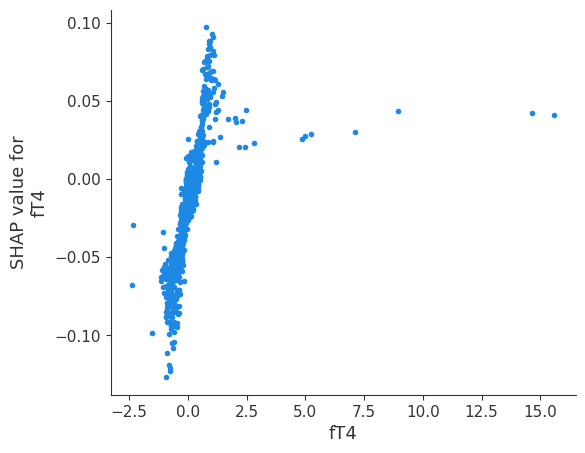

In [12]:
thyroid_features = [c for c in X_test.columns if c not in config.CARDIO]
if not shap_summary.empty and thyroid_features:
    import shap
    best_thyroid = (shap_summary[shap_summary["block"] == "thyroid"]
                    .iloc[0]["feature"])
    for feature in [shap_summary.iloc[0]["feature"], best_thyroid]:
        fig = plt.figure()
        shap.dependence_plot(feature, values, transformed, show=False,
                             interaction_index=None)
        utils.save_fig(plt.gcf(), f"shap_dependence_{feature}_{ARM}")
        plt.show()

In [13]:
utils.write_manifest(
    config.RESULTS_DIR / f"explainability_manifest_{ARM}.json",
    stage="4_feature_cluster_explainability",
    explained_arm=ARM, feature_set=feature_set, threshold=float(threshold),
    baseline_test_f1_macro=float(baseline_f1),
    shap_member=(str(shap_summary["explained_member"].iloc[0])
                 if not shap_summary.empty else None),
    note="Post-development analysis of a frozen model; nothing was refitted.")
print("explainability stage complete")

explainability stage complete
